In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_json('grocery_chain_data.json')

In [12]:
df.head(5)

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26T00:00:00.000,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13T00:00:00.000,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23T00:00:00.000,Bakery,Onions,4,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13T00:00:00.000,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13T00:00:00.000,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   int64  
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 170.3+ KB


<Axes: xlabel='transaction_date', ylabel='Count'>

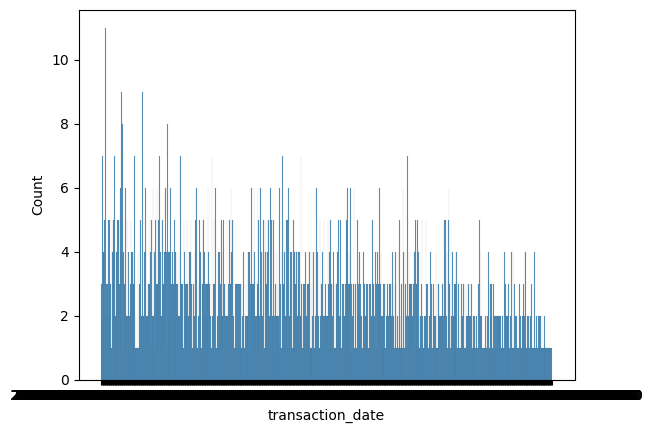

In [5]:
sns.histplot(df['transaction_date'])


<Axes: xlabel='total_amount', ylabel='Count'>

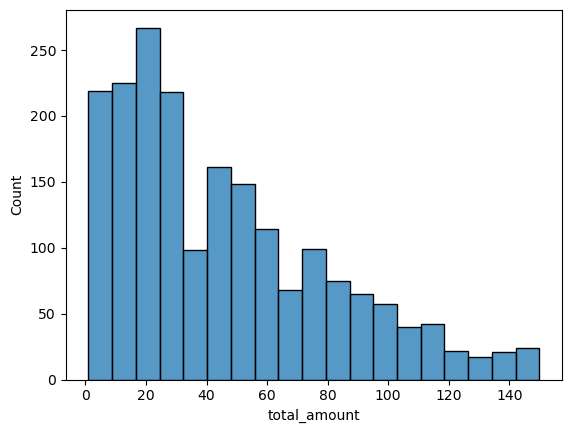

In [6]:
sns.histplot(df['total_amount'])

**Segmentar el tipo de cliente a "normal", "selecto" y "premium"**

1. Filtrar de acuerdo con los promedios de puntos leales las tres secciones.

In [7]:
tipo_clientes = df.groupby('customer_id')['loyalty_points'].mean()
print(tipo_clientes)

customer_id
1006      5.0
1009    330.0
1018    478.0
1023    381.0
1040    101.0
        ...  
9972    200.0
9976    282.0
9977    196.0
9984    179.0
9998    202.0
Name: loyalty_points, Length: 1798, dtype: float64


In [8]:
df_clientes = tipo_clientes.to_frame(name='promedio_puntos')

df_clientes['segmento'] = 'normal' 
df_clientes.loc[(df_clientes['promedio_puntos'] > 50) & (df_clientes['promedio_puntos'] <= 250), 'segmento'] = 'selecto'
df_clientes.loc[df_clientes['promedio_puntos'] > 250, 'segmento'] = 'premium'

print(df_clientes.head())

             promedio_puntos segmento
customer_id                          
1006                     5.0   normal
1009                   330.0  premium
1018                   478.0  premium
1023                   381.0  premium
1040                   101.0  selecto


In [9]:
conteo_normal = df_clientes.groupby('segmento').count()
print(conteo_normal)

          promedio_puntos
segmento                 
normal                177
premium               951
selecto               670


In [10]:
# Guardamos el resultado en un CSV para que Tableau lo pueda leer
df_clientes.to_csv('datos_para_tableau.csv', index=True)

In [11]:
print(df_clientes['segmento'].unique())

['normal' 'premium' 'selecto']
